<a href="https://colab.research.google.com/github/ahemdabdulrahman15-collab/mlproject/blob/main/ch2_handsOnML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


1. Look at the big picture.

2. Get the data.

3. Discover and visualize the data to gain insights.

4. Prepare the data for Machine Learning algorithms.

5. Select a model and train it.

6. Fine-tune your model.

7. Present your solution.

8. Launch, monitor, and maintain your system.

#1. Look at the big picture.


## Business Objective:

Develop a machine learning model that predicts the median house price of a district.
The predictions will be used by a downstream investment system to identify profitable areas for real estate investment, helping the company make better investment decisions and increase revenue.

# 2. Get the data.

In [1]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH  = os.path.join("datasets" , "housing")
HOUSING_URL   = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
  if not os.path.isdir(housing_path):
    os.makedirs(housing_path)
  tgz_path = os.path.join(housing_path, "housing.tgz")
  urllib.request.urlretrieve(housing_url, tgz_path)
  housing_tgz = tarfile.open(tgz_path)
  housing_tgz.extractall(path=housing_path)
  housing_tgz.close()

In [2]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
  csv_path = os.path.join(housing_path, "housing.csv")
  return pd.read_csv(csv_path)

In [3]:
fetch_housing_data()
housing = load_housing_data()
housing.head()

/tmp/ipykernel_917/951082052.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#3- Discover and Visualize the Data to Gain Insights

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

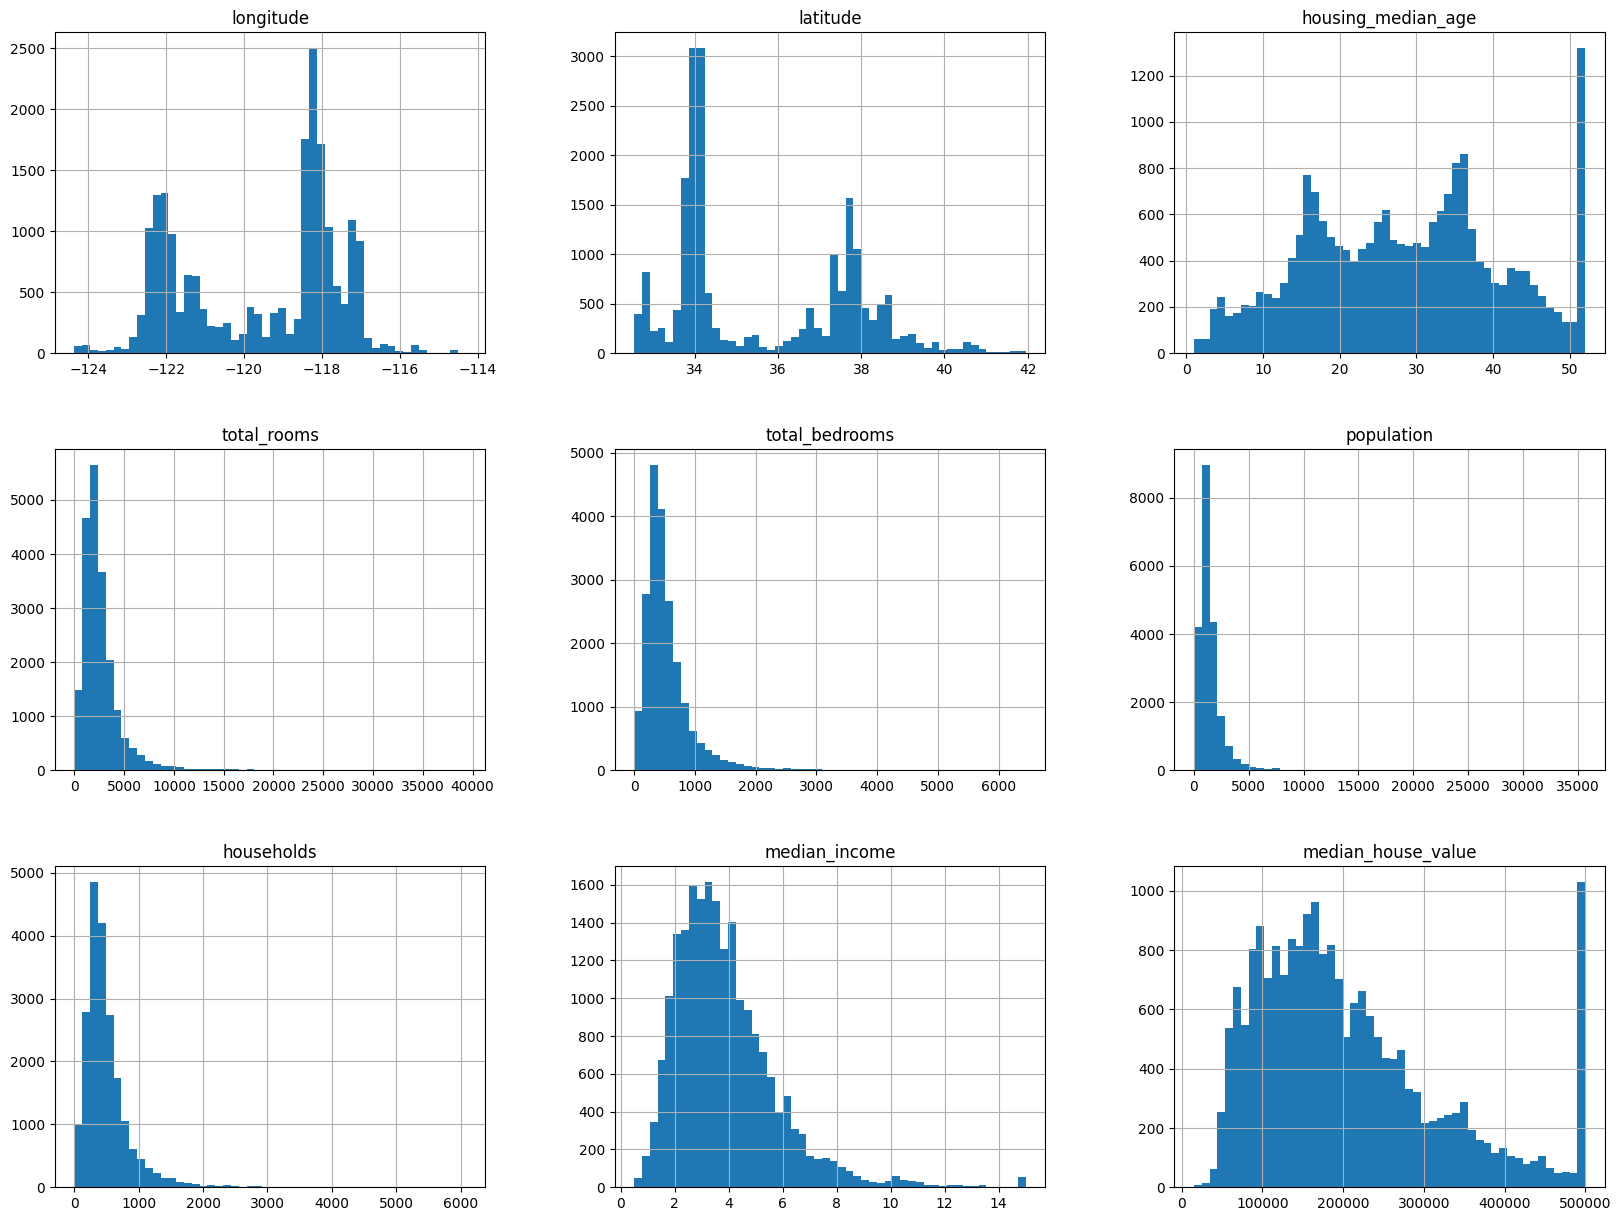

In [7]:
import matplotlib as plt
housing.hist(bins= 50 , figsize=(20 , 15 ))

In [8]:
import numpy as np
housing['income_cat'] = pd.cut(housing['median_income'] ,
                               bins=[0. , 1.5 , 3.0 , 4.5 , 6. ,
                               np.inf] , labels=[1 , 2 , 3 , 4 , 5])

<Axes: >

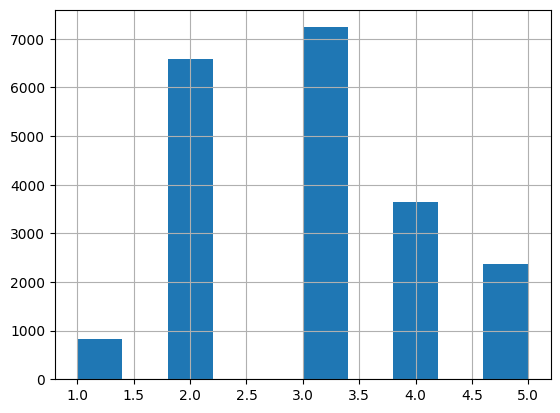

In [9]:
housing['income_cat'].hist()

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits= 1 , test_size= 0.2 , random_state= 42)
for train_index , test_index in split.split(housing , housing['income_cat']):
  strat_train_set = housing.loc[train_index]
  strat_test_set = housing.loc[test_index]


In [11]:
strat_test_set['income_cat'].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [12]:
for set_ in (strat_train_set , strat_test_set):
  set_.drop("income_cat" , axis = 1 , inplace = True)

In [13]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


In [14]:
housing = strat_train_set.copy()
housing.shape

(16512, 10)

<Axes: xlabel='longitude', ylabel='latitude'>

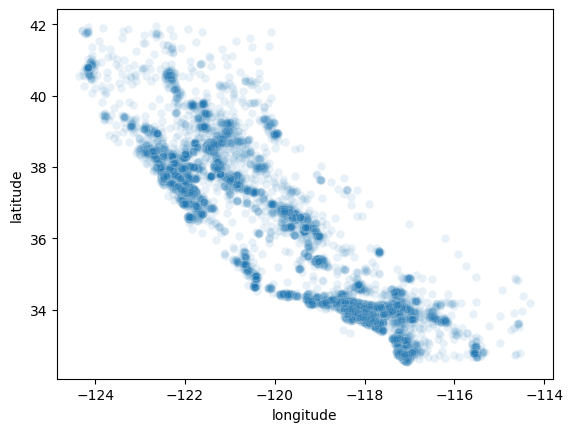

In [15]:
import seaborn as sns

sns.scatterplot(data = housing , x = "longitude" , y = "latitude" , alpha = 0.1)

<Axes: xlabel='longitude', ylabel='latitude'>

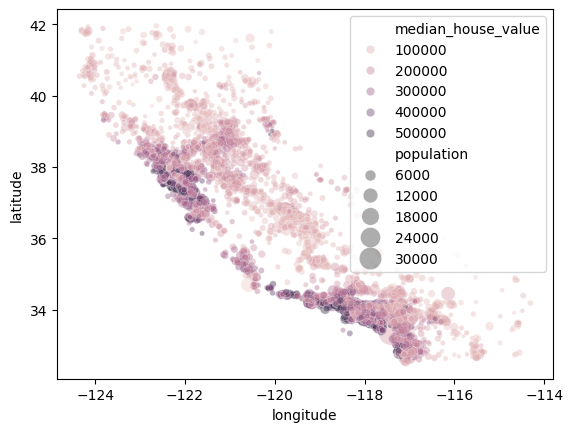

In [16]:
sns.scatterplot(
    data=housing,
    x="longitude",
    y="latitude",
    size="population",
    sizes=(10, 300),              # Min and max marker size
    hue="median_house_value",
    alpha=0.4,
    legend="brief"
)

<Axes: xlabel='longitude', ylabel='latitude'>

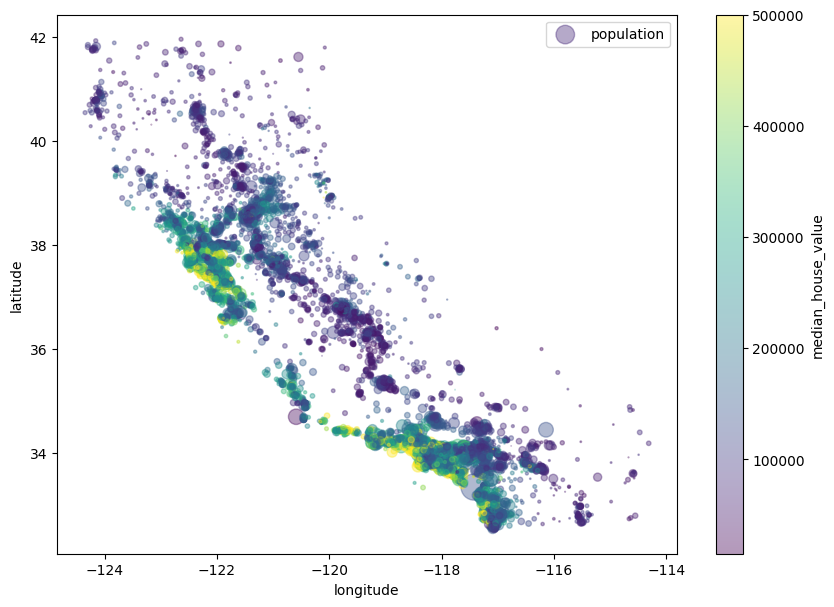

In [17]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
s=housing["population"]/100, label="population", figsize=(10,7),
c="median_house_value", colorbar=True,
)
# plt.legend()

In [18]:
numarical_columns = list(housing.select_dtypes(include=np.number))
numarical_columns

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [19]:
corr_matrix = housing[numarical_columns].corr()
corr_matrix['median_house_value'].sort_values(ascending=False)
#

,median_house_value
median_house_value,1.000000
median_income,0.687151
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047781
population,-0.026882
longitude,-0.047466
latitude,-0.142673


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

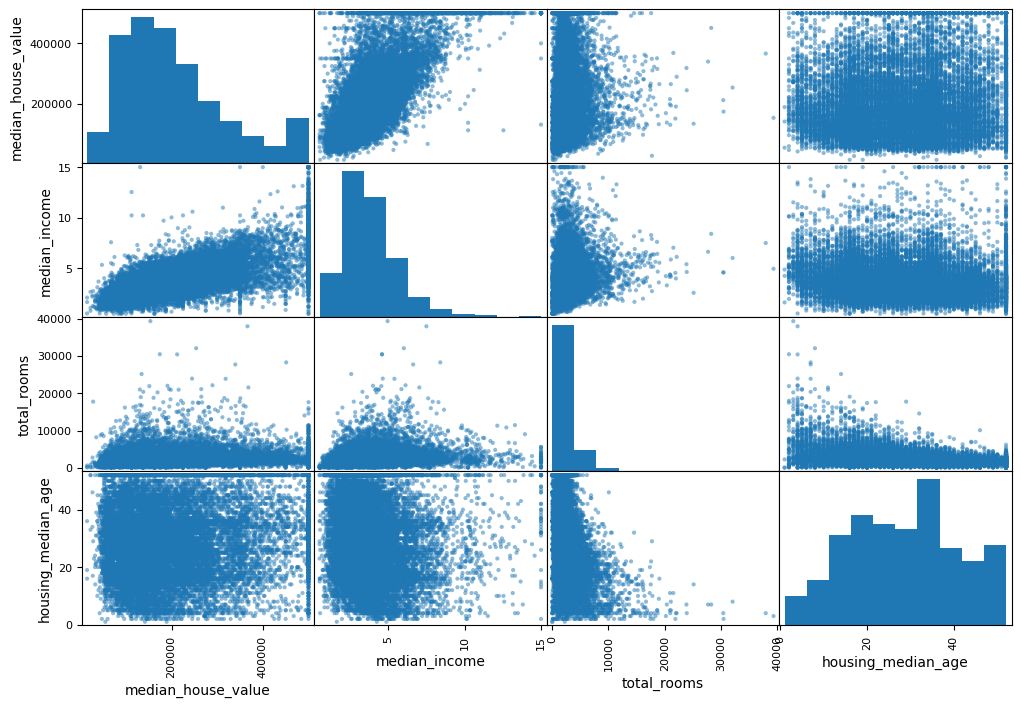

In [20]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

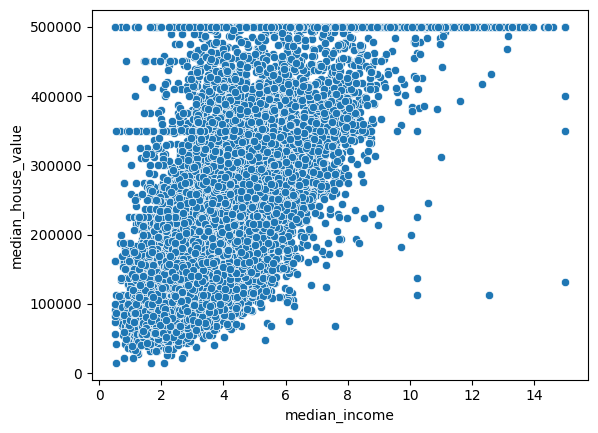

In [21]:
sns.scatterplot(data= housing , x = 'median_income' , y = 'median_house_value')

In [22]:
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']
housing['bedrooms_per_room']   = housing['total_bedrooms'] / housing['total_rooms']
housing['population_per_household'] = housing['population'] / housing['households']
numarical_columns = list(housing.select_dtypes(include=np.number))
corr_matrix = housing[numarical_columns].corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.687151
rooms_per_household,0.146255
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047781
population_per_household,-0.021991
population,-0.026882
longitude,-0.047466


# 4- Prepare the Data for Machine Learning Algorithms

In [23]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [24]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1)
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [25]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [26]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [27]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X , columns = housing_num.columns)

## Handling Text and Categorical Attributes

In [28]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing[["ocean_proximity"]])
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [29]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

## Custom Transformers

In [30]:
from sklearn.base import BaseEstimator , TransformerMixin
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]
att_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra = att_adder.transform(housing.values)

##Transformation Pipelines


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipline = Pipeline([
    ('imputer' , SimpleImputer(strategy="median")),
    ('attribs_adder' , CombinedAttributesAdder()),
    ('std_scaler' , StandardScaler())
])
housing_num_tr = num_pipline.fit_transform(housing_num)

In [32]:
housing_num_tr

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.01739526,
         0.00622264, -0.12112176],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.56925554,
        -0.04081077, -0.81086696],
       [ 0.26758118, -0.1259716 ,  1.22045984, ..., -0.01802432,
        -0.07537122, -0.33827252],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ..., -0.5092404 ,
        -0.03743619,  0.32286937],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.32814891,
        -0.05915604, -0.45702273],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.01407228,
         0.00657083, -0.12169672]])

In [33]:
from sklearn.compose import ColumnTransformer
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]
full_pipline = ColumnTransformer([
    ("num" , num_pipline , num_attribs),
    ("cat" , OneHotEncoder() , cat_attribs)
])
housing_prepared = full_pipline.fit_transform(housing)

In [34]:
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

#5. Select a model and train it.


In [35]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [36]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))


Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [37]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

In [38]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor()

In [39]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

## Better Evaluation Using Cross-Validation

In [40]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    tree_reg,
    housing_prepared,
    housing_labels,
    scoring = "neg_mean_squared_error",
    cv = 10
)
tree_rmse_scores = np.sqrt(-scores)

In [41]:
tree_rmse_scores

array([72729.1041118 , 70060.77797237, 67911.15975793, 71997.62476932,
       69168.60629085, 77388.1257898 , 69683.18906454, 74045.87291497,
       68496.29099973, 72430.87081515])

In [42]:
def display_scores(scores):
     print("Scores:", scores)
     print("Mean:", scores.mean())
     print("Standard deviation:", scores.std())


display_scores(tree_rmse_scores)

Scores: [72729.1041118  70060.77797237 67911.15975793 71997.62476932
 69168.60629085 77388.1257898  69683.18906454 74045.87291497
 68496.29099973 72430.87081515]
Mean: 71391.16224864699
Standard deviation: 2763.4667746540827


In [43]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,scoring="neg_mean_squared_error", cv=10)

lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
Standard deviation: 2880.3282098180694


In [44]:
from sklearn.ensemble import  RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
display_scores(forest_rmse)

Scores: 18679.92952063319
Mean: 18679.92952063319
Standard deviation: 0.0


In [45]:
my_model = forest_reg

In [46]:
import joblib
joblib.dump(my_model, "my_model.pkl")
my_model_loaded = joblib.load("my_model.pkl")

#6. Fine-tune your model.

In [47]:
from sklearn.model_selection import GridSearchCV
param_grid =  [
    {'n_estimators' : [3, 10 , 30] , 'max_features' : [2 , 4 , 6 , 8]},
    {'bootstrap' : [False] , 'n_estimators' : [3 , 10] , 'max_features' : [2 , 3 ,4]}
]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg , param_grid , cv = 5 , scoring = 'neg_mean_squared_error' , return_train_score = True)
grid_search.fit(housing_prepared , housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [48]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [49]:
cvres = grid_search.cv_results_
for mean_score , params in zip(cvres["mean_test_score"] , cvres["params"]):
  print(np.sqrt(-mean_score) , params)

63419.64377395091 {'max_features': 2, 'n_estimators': 3}
54969.38933392917 {'max_features': 2, 'n_estimators': 10}
53010.43500571511 {'max_features': 2, 'n_estimators': 30}
60271.127440159624 {'max_features': 4, 'n_estimators': 3}
52751.119284620465 {'max_features': 4, 'n_estimators': 10}
50206.00087199804 {'max_features': 4, 'n_estimators': 30}
58820.29779506444 {'max_features': 6, 'n_estimators': 3}
52225.753634770306 {'max_features': 6, 'n_estimators': 10}
50198.49962125593 {'max_features': 6, 'n_estimators': 30}
59332.37037997306 {'max_features': 8, 'n_estimators': 3}
52425.25029420602 {'max_features': 8, 'n_estimators': 10}
50115.62305335867 {'max_features': 8, 'n_estimators': 30}
62035.48036574723 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54255.150120065075 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59830.86219174591 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52622.33885576893 {'bootstrap': False, 'max_features': 3, 'n_estimators'

In [50]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([6.95114628e-02, 6.06697338e-02, 4.37618598e-02, 1.68558782e-02,
       1.55256068e-02, 1.59279545e-02, 1.42263261e-02, 3.68500841e-01,
       4.64823170e-02, 1.09986070e-01, 5.80470660e-02, 6.25738835e-03,
       1.68983868e-01, 7.62736455e-05, 2.29699570e-03, 2.89035904e-03])

In [54]:
extra_attribs = ["rooms_per_household", "pop_per_household", "bedrooms_per_room"]
cat_encoder = full_pipline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.36850084082319606), 'median_income'),
 (np.float64(0.1689838678298682), 'INLAND'),
 (np.float64(0.10998606954112831), 'pop_per_household'),
 (np.float64(0.06951146278450543), 'longitude'),
 (np.float64(0.0606697337854061), 'latitude'),
 (np.float64(0.058047065978307305), 'bedrooms_per_room'),
 (np.float64(0.0464823170422309), 'rooms_per_household'),
 (np.float64(0.04376185975742774), 'housing_median_age'),
 (np.float64(0.01685587819674398), 'total_rooms'),
 (np.float64(0.015927954528175803), 'population'),
 (np.float64(0.01552560684748913), 'total_bedrooms'),
 (np.float64(0.014226326148730567), 'households'),
 (np.float64(0.0062573883530504994), '<1H OCEAN'),
 (np.float64(0.0028903590407320435), 'NEAR OCEAN'),
 (np.float64(0.0022969956974831876), 'NEAR BAY'),
 (np.float64(7.627364552470836e-05), 'ISLAND')]

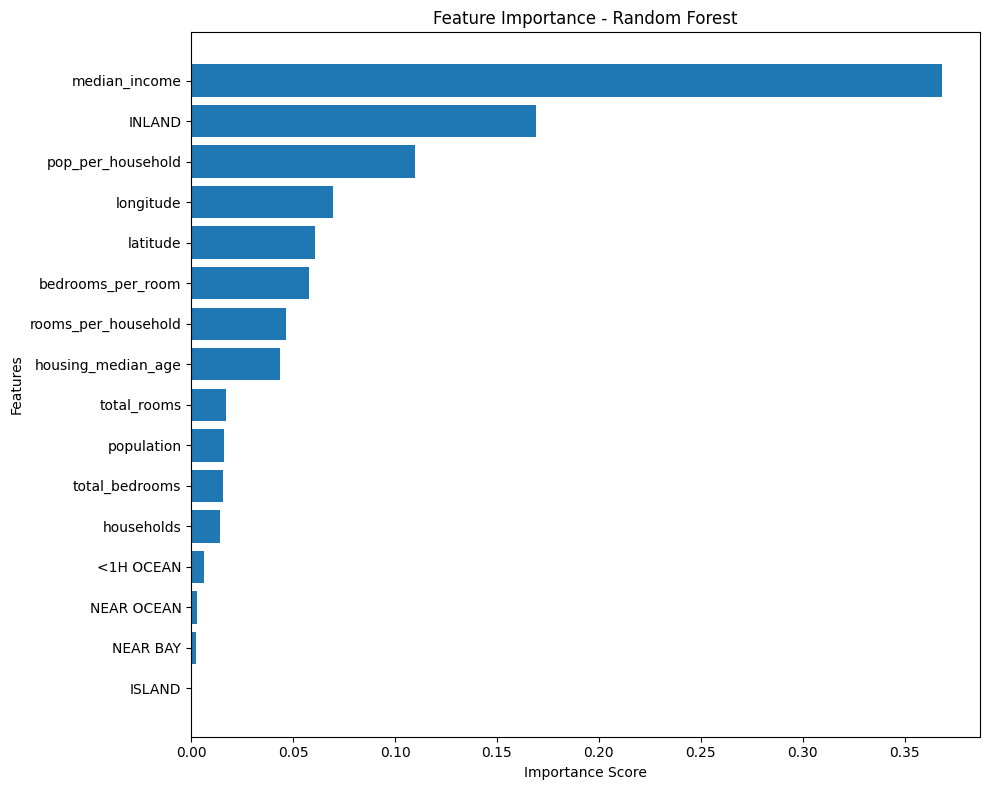

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    "Feature": attributes,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,8))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#7. Present your solution.

## Evaluate Your System on the Test Set

In [57]:
final_model = grid_search.best_estimator_
X_test = strat_test_set.drop("median_house_value" , axis = 1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test , final_predictions)
final_rmse = np.sqrt(final_mse)

In [61]:
print(final_rmse)
print(final_model)

47723.2236439295
RandomForestRegressor(max_features=8, n_estimators=30)


In [ ]:
X_tes